# Notebook de test des modules 

## Imports et configuration

In [1]:
### IMPORTS GENERAUX ###
import os
import sys
import glob
from tqdm.notebook import tqdm
import sacrebleu
import torch
import torch.nn as nn
from torch import optim
import matplotlib.pyplot as plt


### IMPORTS MODULES ###
sys.path.append(os.path.abspath('./src'))
from data_loader import load_mtedx_data
from asr_pipeline import AudioTranscriber
from lstm_baseline import Lang, EncoderRNN, DecoderRNN, tensorFromSentence, train_epoch, evaluate_lstm
from nmt_pipeline import SubtitleTranslator, MultilingualTranslator
from metrics import evaluate_asr, evaluate_nmt

### CONF PATHS ###

BASE_DIR = os.getcwd()

DATA_DIR = os.path.join(os.path.abspath(BASE_DIR), 'data')
OUTPUT_DIR = os.path.join(os.path.abspath(BASE_DIR), 'output')

# Chemins spécifiques datasets test FR
FR_TEST_DIR = os.path.join(os.path.abspath(DATA_DIR), 'fr-fr', 'data', 'test')
FR_WAV_TEST_DIR = os.path.join(FR_TEST_DIR, 'wav')
FR_TXT_TEST_DIR = os.path.join(FR_TEST_DIR, 'txt')
FR_VTT_TEST_DIR = os.path.join(FR_TEST_DIR, 'vtt')

# Chemins spécifiques datasets test EN
EN_TEST_DIR = os.path.join(os.path.abspath(DATA_DIR), 'fr-en', 'data', 'test')
EN_WAV_TEST_DIR = os.path.join(EN_TEST_DIR, 'wav')
EN_TXT_TEST_DIR = os.path.join(EN_TEST_DIR, 'txt')
EN_VTT_TEST_DIR = os.path.join(EN_TEST_DIR, 'vtt')

# Chemins spécifiques datasets test ES
ES_TEST_DIR = os.path.join(os.path.abspath(DATA_DIR), 'fr-es', 'data', 'test')
ES_WAV_TEST_DIR = os.path.join(ES_TEST_DIR, 'wav')
ES_TXT_TEST_DIR = os.path.join(ES_TEST_DIR, 'txt')
ES_VTT_TEST_DIR = os.path.join(ES_TEST_DIR, 'vtt')

# Chemins spécifiques datasets test PT
PT_TEST_DIR = os.path.join(os.path.abspath(DATA_DIR), 'fr-pt', 'data', 'test')
PT_WAV_TEST_DIR = os.path.join(PT_TEST_DIR, 'wav')
PT_TXT_TEST_DIR = os.path.join(PT_TEST_DIR, 'txt')
PT_VTT_TEST_DIR = os.path.join(PT_TEST_DIR, 'vtt')


## Chargement des données

In [3]:
print(f"Chargement des données depuis {DATA_DIR}...")

datasets = load_mtedx_data(DATA_DIR, pairs=['fr-en','fr-es'])

print("\n---- Résultats du chargement ----")
print("Paires de langues chargées :", datasets.keys())

if 'fr-en' in datasets:
    print("\nSplits disponibles pour fr-en :", datasets['fr-en'].keys())
    print(f"Nombre de segments audio (train): {len(datasets['fr-en']['train'])}")

    print("\nExemple de segment audio (segment 0) :")
    exemple = datasets['fr-en']['train'][0]
    for key, value in exemple.items():
        print(f"{key}: {value[:100]}...")

Chargement des données depuis /home/dylan/COURS/M2_COURS/deep_learning/projet_deeplearning/data...
fr-en - train chargé : 30171 phrases.
fr-en - valid chargé : 1036 phrases.
fr-en - test chargé : 1059 phrases.
fr-es - train chargé : 20826 phrases.
fr-es - valid chargé : 1036 phrases.
fr-es - test chargé : 1059 phrases.

---- Résultats du chargement ----
Paires de langues chargées : dict_keys(['fr-en', 'fr-es'])

Splits disponibles pour fr-en : dict_keys(['train', 'valid', 'test'])
Nombre de segments audio (train): 30171

Exemple de segment audio (segment 0) :
src_text: Je m'appelle Julien Le Breton et, comme mon nom ne l'indique pas, je suis né et j'habite en Nouvelle...
tgt_text: I'm Julien Le Breton and as my name doesn't suggest, I was born and live in New Caledonia....


## Transcription sur un fichier audio et evaluation de l'ASR

In [4]:
print("=== ÉVALUATION ASR (Français) ===")

segments_file = os.path.join(FR_TXT_TEST_DIR, "segments")
text_fr_file = os.path.join(FR_TXT_TEST_DIR, "test.fr")

references_par_audio = {}
if os.path.exists(segments_file) and os.path.exists(text_fr_file):
    with open(segments_file, 'r', encoding='utf-8') as f_seg, open(text_fr_file, 'r', encoding='utf-8') as f_txt:
        segments_lines = f_seg.readlines()
        text_lines = f_txt.readlines()
        
        # On associe chaque ligne de test.fr à son identifiant audio grâce au fichier segments
        for seg_line, txt_line in zip(segments_lines, text_lines):
            parts = seg_line.strip().split()
            if len(parts) >= 2:
                recording_id = parts[1] # ex: '0u7tTptBo9I'
                texte = txt_line.strip()
                if recording_id not in references_par_audio:
                    references_par_audio[recording_id] = []
                references_par_audio[recording_id].append(texte)

# B. Joindre les phrases pour faire un texte complet par fichier audio
for rec_id in references_par_audio:
    references_par_audio[rec_id] = " ".join(references_par_audio[rec_id])

# C. Lancer Whisper et évaluer
transcripteur = AudioTranscriber(model_name="openai/whisper-small")
hypotheses_asr = []
references_asr = []

# LIMITE : On n'évalue que les 2 premiers fichiers audio pour le test. 
# Enlève `[:2]` pour évaluer tout le dataset (ça prendra du temps !)
fichiers_a_evaluer = list(references_par_audio.keys())[:2]

for rec_id in tqdm(fichiers_a_evaluer, desc="Transcription ASR"):
    # Tu as bien précisé que ce sont des .flac dans le dossier wav !
    audio_path = os.path.join(FR_WAV_TEST_DIR, f"{rec_id}.flac") 
    
    if os.path.exists(audio_path):
        # On utilise le pipeline pour extraire le texte complet
        result = transcripteur.pipe(audio_path, generate_kwargs={"language": "french", "task": "transcribe"})
        hypotheses_asr.append(result["text"])
        references_asr.append(references_par_audio[rec_id])
    else:
        print(f"Audio introuvable : {audio_path}")

# D. Calcul des scores ASR
if hypotheses_asr:
    scores_asr = evaluate_asr(references_asr, hypotheses_asr)
    print(f"Résultats ASR : WER = {scores_asr['WER']}%, CER = {scores_asr['CER']}%\n")
    

=== ÉVALUATION ASR (Français) ===
Chargement du modèle ASR 'openai/whisper-small' sur : cuda:0...


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'return_timestamps'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


Transcription ASR:   0%|          | 0/2 [00:00<?, ?it/s]

A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.
Whisper did not predict an endi

Résultats ASR : WER = 21.14%, CER = 17.42%



## Approche 1 : LSTM entrainé sur des données de parole et evaluation 

=== ENTRAÎNEMENT COMPLET DE LA BASELINE LSTM ===
Utilisation de l'appareil : cuda
fr-en - train chargé : 30171 phrases.
fr-en - valid chargé : 1036 phrases.
fr-en - test chargé : 1059 phrases.
Taille du jeu d'entraînement : 30171 phrases.
Construction des vocabulaires...
Mots uniques FR : 44758
Mots uniques EN : 37536

Début de l'entraînement massif...


Epoch 1/10:   0%|          | 0/30171 [00:00<?, ?it/s]

Epoch 1 terminée | Loss moyenne : 5.7567


Epoch 2/10:   0%|          | 0/30171 [00:00<?, ?it/s]

Epoch 2 terminée | Loss moyenne : 5.5428


...

Epoch 8 terminée | Loss moyenne : 4.6415


Epoch 9/10:   0%|          | 0/30171 [00:00<?, ?it/s]

Epoch 9 terminée | Loss moyenne : 4.5458


Epoch 10/10:   0%|          | 0/30171 [00:00<?, ?it/s]

Epoch 10 terminée | Loss moyenne : 4.4395

Modèle sauvegardé dans /home/dylan/COURS/M2_COURS/deep_learning/projet_deeplearning/output/models


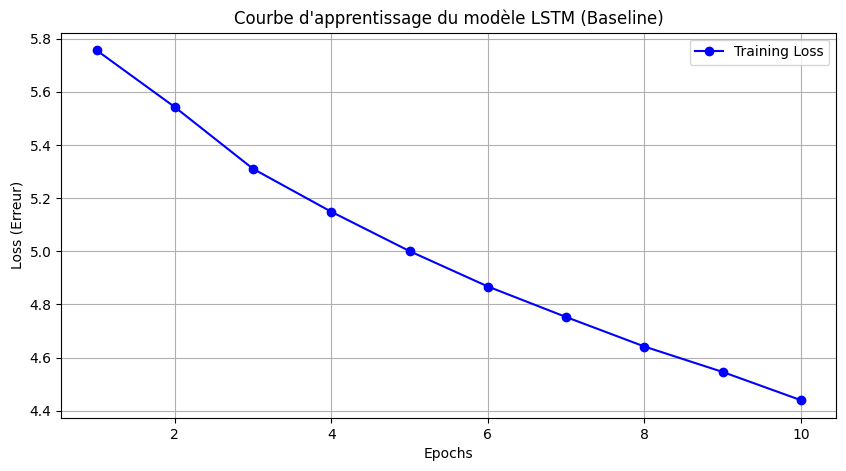


=== Évaluation du modèle LSTM (BLEU Score) ===


Traduction du Test Set:   0%|          | 0/200 [00:00<?, ?it/s]


🏆 SCORE BLEU DU LSTM : 1.45

Exemple de traduction LSTM vs Référence :
FR  : bonsoir !
Vrai: good evening.
LSTM: 


In [2]:
print("=== ENTRAÎNEMENT COMPLET DE LA BASELINE LSTM ===")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil : {device}")

# 1. Chargement des données (Français -> Anglais)
datasets = load_mtedx_data(DATA_DIR, pairs=['fr-en'])

# On passe à un gros entraînement : 30 000 phrases !
# (Tu peux mettre len(datasets['fr-en']['train']) pour utiliser tout le dataset)
# TRAIN_SIZE = 30000 
TRAIN_SIZE = len(datasets['fr-en']['train'])
# Sécurité si le dataset est un peu plus petit
# TRAIN_SIZE = min(TRAIN_SIZE, len(datasets['fr-en']['train']))
train_data = datasets['fr-en']['train'].select(range(TRAIN_SIZE))

print(f"Taille du jeu d'entraînement : {TRAIN_SIZE} phrases.")

# 2. Construction du vocabulaire
print("Construction des vocabulaires...")
input_lang = Lang("fr")
output_lang = Lang("en")

for item in train_data:
    input_lang.add_sentence(item['src_text'].lower())
    output_lang.add_sentence(item['tgt_text'].lower())

print(f"Mots uniques FR : {input_lang.n_words}")
print(f"Mots uniques EN : {output_lang.n_words}")

# 3. Initialisation du modèle LSTM
hidden_size = 256
encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder = DecoderRNN(hidden_size, output_lang.n_words).to(device)

learning_rate = 0.01
encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(ignore_index=2)

# 4. Boucle d'entraînement avec suivi de la Loss
epochs = 10 # On augmente le nombre de passages
loss_history = []

print("\nDébut de l'entraînement massif...")
for epoch in range(1, epochs + 1):
    total_loss = 0
    for item in tqdm(train_data, desc=f"Epoch {epoch}/{epochs}"):
        input_tensor = tensorFromSentence(input_lang, item['src_text'].lower(), device)
        target_tensor = tensorFromSentence(output_lang, item['tgt_text'].lower(), device)
        
        loss = train_epoch(input_tensor, target_tensor, encoder, decoder, 
                           encoder_optimizer, decoder_optimizer, criterion, device)
        total_loss += loss
        
    avg_loss = total_loss / len(train_data)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch} terminée | Loss moyenne : {avg_loss:.4f}")

# --- SAUVEGARDE DU MODÈLE ---
MODELS_DIR = os.path.join(OUTPUT_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)
torch.save(encoder.state_dict(), os.path.join(MODELS_DIR, "encoder_lstm.pt"))
torch.save(decoder.state_dict(), os.path.join(MODELS_DIR, "decoder_lstm.pt"))
print(f"\nModèle sauvegardé dans {MODELS_DIR}")

# --- GRAPHIQUE DE LA LOSS ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='b', label='Training Loss')
plt.title("Courbe d'apprentissage du modèle LSTM (Baseline)")
plt.xlabel("Epochs")
plt.ylabel("Loss (Erreur)")
plt.grid(True)
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "lstm_loss_curve.png"))
plt.show()

# 5. ÉVALUATION FINALE (Calcul du BLEU)
print("\n=== Évaluation du modèle LSTM (BLEU Score) ===")
# On évalue sur 200 phrases du test set pour comparer avec MarianMT
test_data = datasets['fr-en']['test']
EVAL_SIZE = 200
phrases_test_fr = [item['src_text'].lower() for item in test_data][:EVAL_SIZE]
references_en = [item['tgt_text'].lower() for item in test_data][:EVAL_SIZE]

hypotheses_lstm = []
for phrase in tqdm(phrases_test_fr, desc="Traduction du Test Set"):
    traduction = evaluate_lstm(encoder, decoder, phrase, input_lang, output_lang, device)
    hypotheses_lstm.append(traduction)

# Calcul du BLEU
bleu_lstm = sacrebleu.corpus_bleu(hypotheses_lstm, [references_en]).score
print(f"\n🏆 SCORE BLEU DU LSTM : {bleu_lstm:.2f}")

print("\nExemple de traduction LSTM vs Référence :")
print(f"FR  : {phrases_test_fr[0]}")
print(f"Vrai: {references_en[0]}")
print(f"LSTM: {hypotheses_lstm[0]}")

## Traduction et Evaluation du NMT

In [ ]:
print("=== ÉVALUATION NMT ===")

nmt_src_file = os.path.join(EN_TXT_TEST_DIR, "test.fr")
nmt_tgt_file_en = os.path.join(EN_TXT_TEST_DIR, "test.en")
nmt_tgt_file_es = os.path.join(ES_TXT_TEST_DIR, "test.es")
targets_disponibles = [nmt_tgt_file_en, nmt_tgt_file_es]

ext_model = {
    "en": "Helsinki-NLP/opus-mt-fr-en",
    "es": "Helsinki-NLP/opus-mt-fr-es"
}

for nmt_tgt_file in targets_disponibles:
    extension = os.path.basename(nmt_tgt_file).split(".")[-1]
    print(f"\n--- Évaluation NMT pour la langue cible : {extension.upper()} ---")
    if os.path.exists(nmt_src_file) and os.path.exists(nmt_tgt_file):
        with open(nmt_src_file, 'r', encoding='utf-8') as f_src, open(nmt_tgt_file, 'r', encoding='utf-8') as f_tgt:
            phrases_fr = [line.strip() for line in f_src.readlines()]
            references = [line.strip() for line in f_tgt.readlines()]
        EVAL_SIZE = 100  # Limite à 100 phrases pour l'évaluation
        phrases_fr = phrases_fr[:EVAL_SIZE]
        references = references[:EVAL_SIZE]
        
        model_name = ext_model.get(extension)
        if not model_name:
            print(f"Pas de modèle configuré pour l'extension {extension}")
            continue
        
        traducteur = SubtitleTranslator(model_name=model_name)
        
        hypotheses = []
        for phrase in tqdm(phrases_fr, desc=f"Traduction NMT {extension}"):
            hypotheses.append(traducteur.translate_text(phrase))
            
        scores_nmt = evaluate_nmt(references, hypotheses)
        print(f"Résultats NMT ({extension.upper()}) : BLEU = {scores_nmt['BLEU']}, chrF = {scores_nmt['chrF']}")
    else:
        print(f"Fichiers de traduction introuvables pour {nmt_tgt_file}")

=== ÉVALUATION NMT ===

--- Évaluation NMT pour la langue cible : EN ---
Chargement du modèle NMT 'Helsinki-NLP/opus-mt-fr-en' sur : cuda:0...


Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

Traduction NMT en:   0%|          | 0/100 [00:00<?, ?it/s]

Résultats NMT (EN) : BLEU = 42.99, chrF = 64.52

--- Évaluation NMT pour la langue cible : ES ---
Chargement du modèle NMT 'Helsinki-NLP/opus-mt-fr-es' sur : cuda:0...


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Traduction NMT es:   0%|          | 0/100 [00:00<?, ?it/s]

Résultats NMT (ES) : BLEU = 49.77, chrF = 69.28

--- Évaluation NMT pour la langue cible : PT ---
Pas de modèle configuré pour l'extension pt


## Approche NLLB-200 et evaluation 

In [3]:

print("=== TEST DU MODÈLE MASSIVEMENT MULTILINGUE (NLLB-200) ===")

# 1. On charge le modèle (il pèse environ 2.5 Go, le téléchargement peut prendre 1 à 2 min)
traducteur_multi = MultilingualTranslator(model_name="facebook/nllb-200-distilled-600M")

# 2. La phrase de test
phrase_test = "Les modèles d'intelligence artificielle permettent aujourd'hui de franchir la barrière de la langue."
print(f"\n🇫🇷 Français (Source) : {phrase_test}\n")

# 3. Dictionnaire des 4 langues cibles avec leurs codes NLLB
langues_cibles = {
    "Anglais": "eng_Latn",
    "Espagnol": "spa_Latn",
    "Portugais": "por_Latn",
    "Allemand": "deu_Latn"
}

# 4. On lance les traductions
for nom_langue, code_langue in langues_cibles.items():
    traduction = traducteur_multi.translate_text(phrase_test, tgt_lang=code_langue)
    print(f"{nom_langue} : {traduction}")

=== TEST DU MODÈLE MASSIVEMENT MULTILINGUE (NLLB-200) ===
Chargement du modèle Multilingue 'facebook/nllb-200-distilled-600M' sur : cuda:0...


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]


🇫🇷 Français (Source) : Les modèles d'intelligence artificielle permettent aujourd'hui de franchir la barrière de la langue.



AttributeError: TokenizersBackend has no attribute lang_code_to_id

## Erreurs en cascade (ASR puis NMT)

In [9]:
print("=== EXPÉRIENCE : LES ERREURS EN CASCADE (ASR -> NMT) POUR TOUTES LES LANGUES ===")

# fichiers source / segments
segments_file = os.path.join(FR_TXT_TEST_DIR, "segments")
test_fr_file = os.path.join(FR_TXT_TEST_DIR, "test.fr")

# configuration des langues cibles
lang_configs = {
    "EN": {"txt": os.path.join(EN_TXT_TEST_DIR, "test.en"),
           "model": "Helsinki-NLP/opus-mt-fr-en"},
    "ES": {"txt": os.path.join(ES_TXT_TEST_DIR, "test.es"),
           "model": "Helsinki-NLP/opus-mt-fr-es"}
}

# lecture du premier enregistrement et indices
with open(segments_file, 'r', encoding='utf-8') as f:
    segments = f.readlines()

first_rec_id = segments[0].split()[1]
print(f"Analyse sur la vidéo ID : {first_rec_id}")

indices_lignes = [i for i, line in enumerate(segments)
                  if line.split()[1] == first_rec_id]

with open(test_fr_file, 'r', encoding='utf-8') as f:
    lignes_fr = f.readlines()

phrases_gt_fr = [lignes_fr[i].strip() for i in indices_lignes]

# étape ASR
audio_path = os.path.join(FR_WAV_TEST_DIR, f"{first_rec_id}.flac")
transcripteur = AudioTranscriber(model_name="openai/whisper-small")

print("\n1/3 - Whisper écoute et transcrit l'audio (ASR)...")
resultat_asr = transcripteur.pipe(audio_path,
                                  generate_kwargs={"language": "french",
                                                   "task": "transcribe"})
chunks_asr_fr = [chunk['text'] for chunk in resultat_asr['chunks']]

# boucle sur les langues cibles
for lang_label, config in lang_configs.items():
    tgt_file = config["txt"]
    if not os.path.exists(tgt_file):
        print(f"\nFichier de référence introuvable pour {lang_label}: {tgt_file}")
        continue

    with open(tgt_file, 'r', encoding='utf-8') as f:
        lignes_tgt = f.readlines()

    phrases_gt_tgt = [lignes_tgt[i].strip() for i in indices_lignes]
    texte_ref = " ".join(phrases_gt_tgt)

    traducteur = SubtitleTranslator(model_name=config["model"])
    print(f"\n--- CIBLE {lang_label} ---")
    print("2/3 - Traduction du texte PARFAIT (Ground Truth)...")
    traductions_gt = [traducteur.translate_text(p) for p in phrases_gt_fr]
    texte_gt = " ".join(traductions_gt)

    print("3/3 - Traduction de la sortie WHISPER (Cascade Error)...")
    traductions_asr = [traducteur.translate_text(c) for c in chunks_asr_fr]
    texte_asr = " ".join(traductions_asr)

    bleu_ideal = sacrebleu.sentence_bleu(texte_gt, [texte_ref]).score
    bleu_cascade = sacrebleu.sentence_bleu(texte_asr, [texte_ref]).score

    print(f"BLEU idéal : {round(bleu_ideal, 2)}")
    print(f"BLEU en cascade : {round(bleu_cascade, 2)}")
    print(f"Perte due à l'audio : -{round(bleu_ideal - bleu_cascade, 2)} points BLEU")

    # extrait qualitatif
    print("\nExtrait qualitatif :")
    print(f"GT FR   : {phrases_gt_fr[0]}")
    print(f"Whisper : {chunks_asr_fr[0].strip()}")
    print(f"Trad GT : {traductions_gt[0]}")
    print(f"Trad ASR: {traductions_asr[0]}")

=== EXPÉRIENCE : LES ERREURS EN CASCADE (ASR -> NMT) POUR TOUTES LES LANGUES ===
Analyse sur la vidéo ID : 0u7tTptBo9I
Chargement du modèle ASR 'openai/whisper-small' sur : cuda:0...


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).



1/3 - Whisper écoute et transcrit l'audio (ASR)...


Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.


...

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]


--- CIBLE EN ---
2/3 - Traduction du texte PARFAIT (Ground Truth)...
3/3 - Traduction de la sortie WHISPER (Cascade Error)...
BLEU idéal : 45.3
BLEU en cascade : 27.2
Perte due à l'audio : -18.1 points BLEU

Extrait qualitatif :
GT FR   : Bonsoir !
Whisper : ... Bonsoir. Notre planète est recouverte à 70 % d'océans, et pourtantrangement on a choisi de l'appeler la Terre. Le poète Edcott Williams a une vision bien plus objective et moins anthropocentrique quand il dit que vu de l'espace, la planète est bleue. Vu de l'espace, elle est le territoire non pas des hommes mais des baleines. Et pourtant, on vient tous de l'océan, c'est le berceau de la vie, même si on l'a oublié.
Trad GT : Good evening!
Trad ASR: ... Good evening. Our planet is covered with 70% oceans, and yet we have chosen to call it Earth. The poet Edcott Williams has a much more objective and less anthropocentric vision when he says that given space, the planet is blue. Seen from space, it is the territory not of humans b

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



--- CIBLE ES ---
2/3 - Traduction du texte PARFAIT (Ground Truth)...
3/3 - Traduction de la sortie WHISPER (Cascade Error)...
BLEU idéal : 51.25
BLEU en cascade : 25.0
Perte due à l'audio : -26.26 points BLEU

Extrait qualitatif :
GT FR   : Bonsoir !
Whisper : ... Bonsoir. Notre planète est recouverte à 70 % d'océans, et pourtantrangement on a choisi de l'appeler la Terre. Le poète Edcott Williams a une vision bien plus objective et moins anthropocentrique quand il dit que vu de l'espace, la planète est bleue. Vu de l'espace, elle est le territoire non pas des hommes mais des baleines. Et pourtant, on vient tous de l'océan, c'est le berceau de la vie, même si on l'a oublié.
Trad GT : ¡Buenas noches!
Trad ASR: El poeta Edcott Williams tiene una visión mucho más objetiva y menos antropocéntrica cuando dice que, visto desde el espacio, el planeta es azul. Visto desde el espacio, es el territorio no de los hombres, sino de las ballenas.
